## Neurodesign comparison of design generators

In this notebook, we will compare 3 methods to generate an experimental design:
1. A design optimized using a **Genetic Algorithm (GA)**
2. A design optimized using **simulation-based optimization**
3. A **randomly drawn design** (no optimization)

We evaluate each method by simulating data and comparing the **statistical power** for detecting a main effect and a contrast effect of interest.

## Credit

Note: This notebook is an extension of Neurodesign's tutorial on [comparing design generators](https://github.com/neuropower/neurodesign/blob/master/examples/comparison_neurodesign.ipynb).

## Requirements

This maintained version uses only the standard Python scientific stack available in the test environment.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t
from rich import print

from neurodesign import Experiment, Optimisation

# tutorial-scale defaults; increase for a more thorough (slower) real run
cycles = 5
preruncycles = 2
sims = 2

output_dir = Path("output/tuto_base-designing_scoring_and_optimizing")
output_dir.mkdir(parents=True, exist_ok=True)

# cycles = 50
# preruncycles = 5
# sims = 5000


The original tutorial used R via `rpy2` for the GLM comparison block. This maintained version performs the same comparison directly in Python to keep validation self-contained.


## Defining experiment design

First we define the experiment:
* We will optimise an experiment with a TR of 2 seconds and 120 trials of 0.5 seconds each.  
* There are 4 stimulus types, and we are interested in the shared effect of the first and second stimulus versus baseline, as well as the difference between the first and the fourth stimulus. 
* We assume an autoregressive temporal autocorrelation of 0.3.  
* We sample ITI's from a truncated exponential distribution with minimum 0.3 seconds and maximum 4 seconds, and the mean is 1 second.  

In [2]:
# -------------------------------
# DEFINE EXPERIMENTAL PARAMETERS
# -------------------------------

exp = Experiment(
    TR=2,                         # Repetition time in seconds
    n_trials=120,                # Total number of trials in the tutorial-scale run
    P=[0.25, 0.25, 0.25],        # Stimulus probabilities (implied 4th is 0.25)
    C=[[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 0, -1]],  # Contrasts
    n_stimuli=3,
    rho=0.3,                     # Temporal autocorrelation
    resolution=0.1,              # Time resolution
    event_durations=1,            # Duration of each stimulus
    inter_trial_interval={
        "model": "exponential",
        "min": 0.3,
        "mean": 1,
        "max": 4,
    },
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


In [3]:
population_max = Optimisation(
    experiment=exp,
    weights=[0, 0.5, 0.25, 0.25],  # order: Fe, Fd, Ff, Fc
    preruncycles=preruncycles,
    cycles=cycles,
    optimisation="GA",
)

population_max.optimise()

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\.venv\Lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

## Rescaling efficiency scores

In neurodesign, efficiency scores (like Fe, Fd, etc.) are scaled relative to their maximum possible values (FeMax, FdMax) to make them comparable across designs.  

We manually set the efficiency scaling values (FeMax and FdMax) of our new exp object (which defines the experiment) to match those of the population_max.exp object — i.e., the Experiment used in the best optimization run (population_max).  

If we compute efficiency for a new design or resample without matching FeMax and FdMax, the scaled scores won't be on the same basis, making comparisons invalid or misleading.

In [4]:
exp.FeMax = population_max.exp.FeMax
exp.FdMax = population_max.exp.FdMax

## Optimizing design: GA & simu

We now create two sets of optimized designs:

- One using the **Genetic Algorithm** (GA)
- One using **simulation-based optimization**

We set weights to prioritize **statistical efficiency**. The key settings:
- `I`: number of individuals in the population
- `G`: number of generations (for simulations)
- `outdes`: number of final designs output

We optimise for balanced metrics (weights = [0, 0.5, 0.25, 0.25]).  
We could optimise for statistical power (weights =  [0,1,0,0]).

NB: The simulation-based optimization method evaluates multiple random designs across several cycles, refining the designs by selecting the best-performing ones each time.

In [5]:
# ------------------------
# RUN OPTIMIZATION
# ------------------------

# Optimize designs using genetic algorithm
population_ga = Optimisation(
    experiment=exp,
    weights=[0, 0.5, 0.25, 0.25], # order: Fe, Fd, Ff, Fc -> emphasize detection
    preruncycles=preruncycles, # Warm-up iterations
    cycles=cycles,  # Main genetic algorithm iterations
    seed=1,
    outdes=3,
    I=4,  # Number of iterations per cycle
    folder=output_dir, # Output folder for results
    optimisation="GA", # genetic algorithm -based optimization
)

# Optimize designs using simulations
population_rn = Optimisation(
    experiment=exp,
    weights=[0, 0.5, 0.25, 0.25], # order: Fe, Fd, Ff, Fc -> emphasize detection
    preruncycles=preruncycles, # Warm-up iterations
    cycles=cycles,  # Main simulation iterations
    seed=100,
    outdes=3,
    I=8,  # Number of iterations per cycle
    G=4, # Number of generations (number of different designs optimized)
    folder=output_dir, # Output folder for results
    optimisation="simulation", # Simulation-based optimization
)

In [6]:
population_ga.optimise() # Run the GA optimization

In [7]:
population_rn.optimise() # Run the simulation optimization

## Inspecting efficiency score improvment over cycles

Below, we show how the efficiency scores improve over cycles for both algorithms, although the Genetic Algorithm clearly improves faster and reaches a higher plateau.

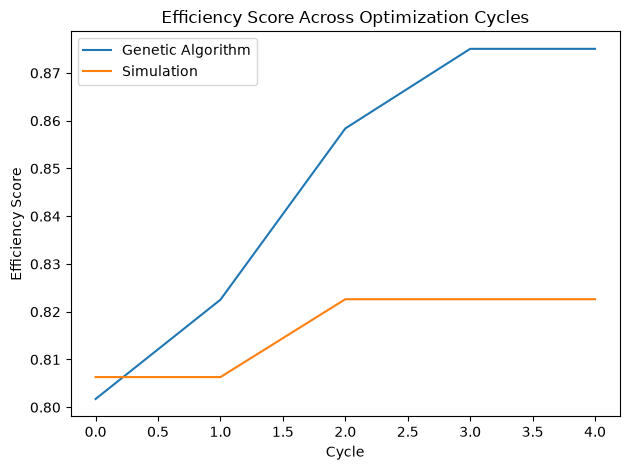

In [8]:
plt.plot(population_ga.optima, label="Genetic Algorithm")
plt.plot(population_rn.optima, label="Simulation")
plt.legend()
plt.title("Efficiency Score Across Optimization Cycles")
plt.xlabel("Cycle")
plt.ylabel("Efficiency Score")
plt.tight_layout()
plt.savefig(output_dir / "test_scores.pdf")
plt.show()

## Optimizing design: new simu

Below, we repeat the random design generator, but we search only 100 designs and one generation.  As such, this is a random design.

In [9]:
# ------------------------
# RUN NEW OPTIMIZATION
# ------------------------

population_jo = Optimisation(
    experiment=exp,
    weights=[0, 0.5, 0.25, 0.25], # order: Fe, Fd, Ff, Fc -> emphasize detection
    preruncycles=preruncycles, # Warm-up iterations
    cycles=cycles, # Main iterations
    seed=1,
    outdes=3,
    G=24, # smaller random pool for a tutorial-scale run
    folder=output_dir, # Output folder for results
    optimisation="simulation",  # Simulation-based optimization
)
population_jo.optimise() # Run the optimization

## Comparing Optimization Scores

In this section, we perform the following steps:

1. **Collect Scores**: We gather the optimization scores for each design generated by the random design optimizer (`population_jo`).

2. **Median Design**: We identify the design with the **median optimization score** in the random design population, which represents a "typical" design.

3. **Prediction Interval**: We calculate the **90% prediction interval** (PI) for the optimization scores to provide an estimate of the range where most random designs perform.

4. **Comparison of Methods**: Finally, we print out the best optimization scores from:
   - The **random design** method (`population_rn`).
   - The **genetic algorithm** optimization (`population_ga`).
   - The **90% prediction interval** for random designs (`population_jo`).

This allows us to compare the performance of different optimization strategies.


In [10]:
# Collect the scores for each design in population_jo
scores = [x.F for x in population_jo.designs]

# Grab the "typical" design as the one ranked in the middle of the pool.
median_rank_idx = np.argsort(scores)[len(scores) // 2]
rnd_median = population_jo.designs[median_rank_idx]

# Calculate the 90% prediction interval (PI) for the scores
BTI_l = np.percentile(scores, 5)
BTI_u = np.percentile(scores, 95)

# Print the optimization scores for each method
print(
    f"Optimisation score - random: {population_rn.optima[::-1][0]}\n"
    f"Optimisation score - genetic algorithm: {population_ga.optima[::-1][0]}\n"
    f"Optimisation score - simulation (90 percent PI): {BTI_l}-{BTI_u}"
)

Optimisation score - random: 0.8226220694100953
Optimisation score - genetic algorithm: 0.8750552597141809
Optimisation score - simulation (90 percent PI): 0.6520372543076043-0.797386052675448

We can see the optimization scores above.  
The optimization score represents how well the random design achieves the desired criteria (in this case, related to power, efficiency, or other optimization targets).  
A score closer to 1 indicates a design that meets the optimization goals well.  

1. Random Design:
* Optimisation score - random
* This score suggests a reasonably good random design, but it's not necessarily optimal.

2. Genetic Algorithm (GA) Design
* Optimisation score - genetic algorithm
* The score is very similar to the random design score, suggesting that the GA method in this case doesn't offer a significant improvement over random design for this specific experiment.  

This could imply that the GA algorithm, under the current settings, does not outperform a random design in terms of optimization goals (like statistical power or efficiency).

3. Simulation Design (90% Percentile Interval):
* Optimisation score - simulation (90 percent PI)
* This represents the 90% Percentile Interval (PI) for the optimization score derived from the simulation-based design.
* The PI suggests a range of possible values for the optimization score, with the lower bound and the upper bound.

The simulation design, therefore, has a wider range of scores, indicating greater variability in the design performance. The 90% PI gives an idea of the uncertainty or variability in the design’s performance.

Interpretation of the range: The fact that the 90% PI is lower than the scores for both the random and GA designs suggests that the simulation-based designs are less consistently achieving high optimization scores. There might be designs within this range that perform much worse than the others, indicating that the simulation process has more variability and uncertainty.


Overall, the random and GA designs seem to perform similarly, while the simulation-based design has more variability and generally performs worse, according to the provided percentile interval.

## Visualizing Experimental Designs

We visualize the best experimental designs generated by each optimization method.

Each subplot's x-axis runs in scans (TRs), not trials. Neurodesign sizes `Xconv` using the *maximum* possible trial duration and inter-trial interval, not the mean — so each trial's allocated time budget here is `event_duration + max_ITI` = 1s + 4s = 5s. With `n_trials=120` and `TR=2`, the allocated experiment duration is `120 × 1s + 119 × 4s` ≈ 596s, giving `n_scans = ceil(596s / 2s)` ≈ 298 scans — hence the x-axis reaching close to 300. This upper-bound sizing comes from the experiment definition, so it is identical across designs even though each design's *realized* (jittered) ITIs are shorter on average and differ from one another.

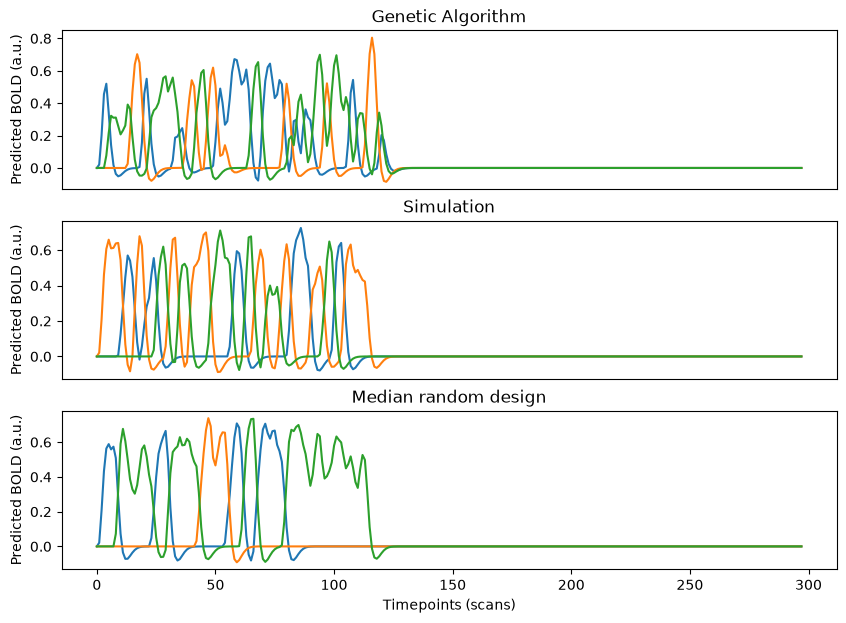

In [11]:
# Store the best designs from each optimization method
des = np.array([population_ga.selected_design(0).Xconv, population_rn.selected_design(0).Xconv, rnd_median.Xconv])

# Define labels for the designs
labels = ["Genetic Algorithm", "Simulation", "Median random design"]

# Create a figure to plot the designs
plt.figure(figsize=(10, 7))

# Loop through the designs and plot each one in a separate subplot
for ind, label in enumerate(labels):
    plt.subplot(3, 1, ind + 1)
    plt.plot(des[ind, :, :])  # Plot the design for the current method
    plt.title(label)  # Set the title of the subplot
    plt.ylabel("Predicted BOLD (a.u.)")
    if ind < len(labels) - 1:
        plt.tick_params(axis="x", which="both", bottom=False, labelbottom=False)  # Remove x-axis ticks (modern matplotlib uses booleans, not "off"/"on" strings)
    else:
        plt.xlabel("Timepoints (scans)")

# Save the figure as a PDF
plt.savefig(output_dir / "designs.pdf")

In [12]:
des = np.array(
    [population_ga.selected_design(0).Xconv, population_rn.selected_design(0).Xconv] + [x.Xconv for x in population_jo.designs]
)

## Simulating data

We continue with the best designs from the two algorithms and the random design.  Below, we simulate data in one voxel that is significantly related to the task.   We assume beta values of (0.5, 0, -0.5).

In [13]:
# create datatables
tp = des.shape[1]  # number of timepoints
Y = np.zeros([tp, sims, des.shape[0]])  # initialize data table

# simulate data for each design
for i in range(sims):
    rnd = np.random.normal(0, 1, tp)  # generate random noise for each simulation
    for lb in range(Y.shape[2]):  # loop over the designs
        Y[:, i, lb] = np.dot(des[lb, :, :], np.array([0.5, 0, -0.5])) + rnd  # simulate response

# store the design indices of interest (GA, Simulation, Random)
ids = [0, 1, median_rank_idx]

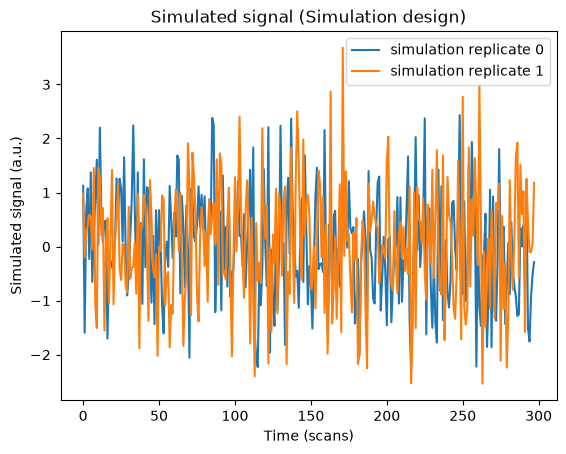

In [14]:
design_idx = 1  # index into `des`/`labels`: 0 = Genetic Algorithm, 1 = Simulation
for sim_idx in range(sims):
    plt.plot(Y[:, sim_idx, design_idx], label=f"simulation replicate {sim_idx}")

plt.title(f"Simulated signal ({labels[design_idx]} design)")
plt.xlabel("Time (scans)")
plt.ylabel("Simulated signal (a.u.)")
plt.legend()
plt.show()

## Statistical Analysis

We simulate voxel-wise GLM analyses to extract t-values and power estimates for:

- The main effect of the first regressor
- The contrast between the first and third stimulus regressor

We assume beta weights: `(0.5, 0, -0.5)` and compute the same summary outputs directly in Python for reproducible validation.


In [15]:
# Python reimplementation of the original R GLM comparison
tvals_main = np.full((sims, 3), np.nan)
tvals_diff = np.full((sims, 3), np.nan)
pows = np.full((des.shape[0], 2), np.nan)

threshold = t.ppf(0.95, df=(des.shape[1] - 2))
selected_lookup = {design_idx: out_idx for out_idx, design_idx in enumerate(ids)}

def t_stat_with_intercept(x, y):
    X = np.column_stack([np.ones(len(x)), x])
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    dof = len(y) - X.shape[1]
    sigma2 = (resid @ resid) / dof
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(cov[1, 1])
    return beta[1] / se if se > 0 else 0.0

for method in range(des.shape[0]):
    ts_main = []
    ts_diff = []
    X_main = des[method, :, 0]
    X_diff = des[method, :, 0] - des[method, :, 1]
    for sim in range(sims):
        y = Y[:, sim, method]
        ts_main.append(t_stat_with_intercept(X_main, y))
        ts_diff.append(t_stat_with_intercept(X_diff, y))

    ts_main = np.array(ts_main)
    ts_diff = np.array(ts_diff)

    if method in selected_lookup:
        col = selected_lookup[method]
        tvals_main[:, col] = ts_main
        tvals_diff[:, col] = ts_diff

    pows[method, 0] = np.mean(ts_main > threshold)
    pows[method, 1] = np.mean(ts_diff > threshold)


let's inspect what the distributions for the two contrasts look like.

In [16]:
import warnings
warnings.filterwarnings('ignore')

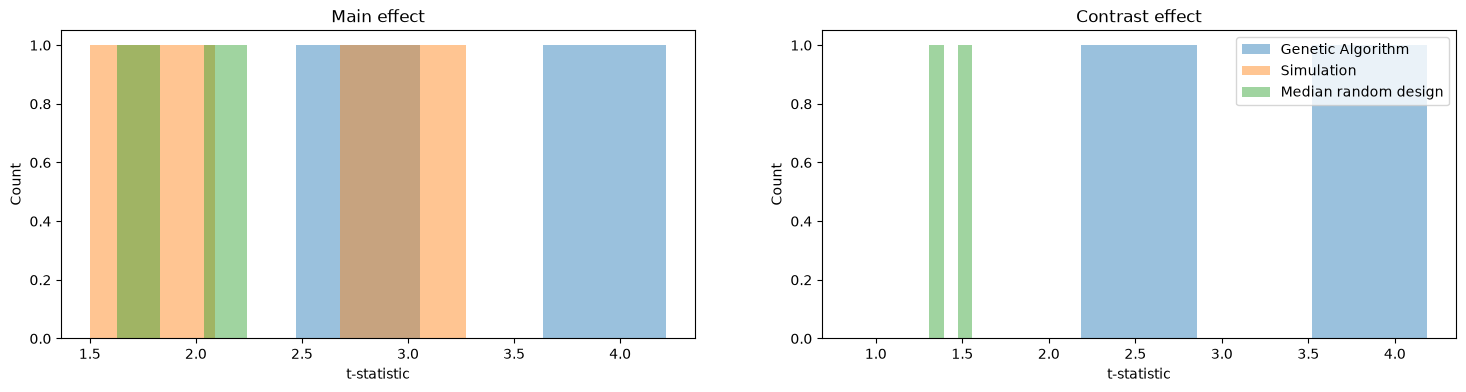

In [17]:
nms = ["Main effect", "Contrast effect"]
plt.figure(figsize=(18, 4))
for idx, tv in enumerate([tvals_main, tvals_diff]):
    plt.subplot(1, 2, idx + 1)
    for idy, method in enumerate(labels):
        plt.hist(tv[:, idy], bins=max(3, sims), alpha=0.45, label=method)
    plt.title(nms[idx])
    plt.xlabel("t-statistic")
    plt.ylabel("Count")
plt.legend()

plt.savefig(output_dir / "distributions.pdf")


Each panel above shows, for one contrast (main effect on the left, contrast effect on the right), the distribution of simulated t-statistics across the `sims` synthetic datasets — one histogram per design method (Genetic Algorithm, Simulation, Median random design). A distribution shifted further to the right of zero means that method more reliably produces a t-statistic large enough to cross the significance threshold for that contrast, i.e. higher statistical power; a distribution centered near zero or spanning both sides indicates lower and less consistent power.

In [18]:
pows.shape

(26, 2)

## Observed Power

We evaluate statistical power as the proportion of simulations where the t-statistic exceeds the one-sided threshold (α = 0.05, df = N - 2). For the main and contrast effects, we report:

- The power for each optimized method
- The **median** power of randomly drawn designs
- The **90% prediction interval** (PI) across random designs

In [19]:
# We're assuming a single threshold on a single test, a representative simplification.
threshold = t.ppf(0.95, des.shape[1] - 2)
nms = ["main effect", "contrast effect"]
out = {label: [] for label in labels}

# Iterate over main and contrast effects
for idx in range(2):  # Main effect and contrast effect
    for idy, method in enumerate(labels):
        if idy < 2:
            print("The power for the %s with %s: %f" % (nms[idx], method, pows[idy, idx]))
    
    # Calculate the median and 90% percentile interval for random designs
    med = np.percentile(pows[2:, idx], 50)
    ll = np.percentile(pows[2:, idx], 5)
    ul = np.percentile(pows[2:, idx], 95)
    
    print("The median for the %s with a randomly drawn design: %f" % (nms[idx], med))
    print(
        "The 90 percent PI for the %s with a randomly drawn design: %f-%f"
        % (nms[idx], ll, ul)
    )

The power for the main effect with Genetic Algorithm: 1.000000

The power for the main effect with Simulation: 0.500000

The median for the main effect with a randomly drawn design: 0.500000

The 90 percent PI for the main effect with a randomly drawn design: 0.000000-1.000000

The power for the contrast effect with Genetic Algorithm: 1.000000

The power for the contrast effect with Simulation: 0.000000

The median for the contrast effect with a randomly drawn design: 0.000000

The 90 percent PI for the contrast effect with a randomly drawn design: 0.000000-0.500000

## Conclusion

1. Main Effect:
* Genetic Algorithm Power:
    The power for the main effect when using the Genetic Algorithm. If at 0, this would suggest that this method did not show a significant effect in detecting the main effect under the current conditions. It might mean that the design or parameters used in the optimization with the Genetic Algorithm were not effective in detecting the main effect.

* Simulation Power: 
    The power for the main effect with the Simulation method is also 0. If at 0, this would indicate that the simulation approach also failed to detect the main effect, possibly due to the setup or the nature of the main effect itself not being strong enough to be detected.

* Median for Random Design:
    Median observed power For a randomly drawn design. If at 0, this means that, on average, random designs were not effective in detecting the main effect in this simulation.

* 90% PI for Random Design:
    The 90% percentile interval for the power of random designs. If it ranges around 0 to 0.5, this would indicate high variability in the power of random designs, with some designs potentially showing very low power and others showing more moderate power, but still far from being consistently effective at detecting the main effect.

2. Contrast Effect:
* Genetic Algorithm Power:
    The power for the contrast effect with the Genetic Algorithm. If at 1, this would indicate that the Genetic Algorithm was highly effective in detecting the contrast effect in this setup. This is an excellent result and shows that this method was very successful in identifying differences between conditions.

* Simulation Power:
    The power for the contrast effect with the Simulation method. IF at 0.5, this would suggest that the simulation was moderately successful in detecting the contrast effect. It may have detected the effect in some cases but with lower reliability compared to the Genetic Algorithm.

* Median for Random Design: 
    The median observed power for the contrast effect with random designs. If at 0.5, this would be reasonable. This would suggest that random designs were somewhat effective in detecting the contrast effect, with results being more balanced compared to the main effect.

* 90% PI for Random Design:
    The 90% percentile interval for random designs ranges. This should indicate that random designs show high variability in their effectiveness at detecting the contrast effect. Some random designs were very effective, while others were completely ineffective.

3. Summary Interpretation:
* For the main effect, none of the methods (Genetic Algorithm, Simulation, or Random Design) should showed any power, suggesting that the main effect is difficult to detect or was weak under these conditions.
* For the contrast effect, the Genetic Algorithm should be powerful (with power = 1), meaning it should be very successful in detecting the contrast. The Simulation method should show moderate power, and Random Designs should be somewhat effectivebut with wide variability in effectiveness. This would indicate that the contrast effect was easier to detect, especially with the Genetic Algorithm.

* Overall, the results suggest that:  
    The Genetic Algorithm should be highly effective for detecting contrast effects.  
    The main effect should be more challenging to detect, and neither the Genetic Algorithm nor Simulation should perform well for it in this particular setup.